<a href="https://colab.research.google.com/github/LCaravaggio/FelicidadDesigualdad/blob/main/Gini_OCDE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import userdata
import json

!mkdir ~/.kaggle
!touch ~/.kaggle/kaggle.json

api_token = {
    'username': userdata.get('KAGGLE_USER'),
    'key': userdata.get('KAGGLE_KEY')}
with open('/root/.kaggle/kaggle.json', 'w') as file:
    json.dump(api_token, file)

!chmod 600 ~/.kaggle/kaggle.json


import kagglehub
path3 = kagglehub.dataset_download("leonardocaravaggio/ge-images4")

100%|██████████| 2.89G/2.89G [01:49<00:00, 28.3MB/s]

Extracting files...


In [2]:
path4 = kagglehub.dataset_download("leonardocaravaggio/ge-images6")

100%|██████████| 1.57G/1.57G [01:06<00:00, 25.3MB/s]

Extracting files...


In [3]:
import pandas as pd
ciudades=pd.read_csv(path3+"/Gini con latlon.csv")

In [4]:
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import numpy as np
import torch.nn.functional as F
import os

# Cargar MobileNetV2 hasta la capa 12
model = models.mobilenet_v2(pretrained=True)
model = torch.nn.Sequential(*list(model.features[:10]))
model.eval()

# Transformaciones de imagen
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Función para extraer características
def extract_index(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0)  # [1, 3, 224, 224]

    with torch.no_grad():
        features = model(image_tensor)  # Pasar por la red
        avg_pool = F.adaptive_avg_pool2d(features, (1, 1)).squeeze()  # [C]
        inequality_index = np.std(avg_pool.cpu().numpy())  # desigualdad

    return inequality_index


# Función para computar desigualdad a múltiples escalas
def compute_inequality(image_10km_path, image_15km_path, image_40km_path):
    return {
        #"Desigualdad_1km": extract_index(image_1km_path),
        #"Desigualdad_5km": extract_index(image_5km_path),
        "Desigualdad_10km": extract_index(image_10km_path),
        "Desigualdad_15km": extract_index(image_15km_path),
        "Desigualdad_40km": extract_index(image_40km_path),
    }

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V2_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V2_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth
100%|██████████| 13.6M/13.6M [00:00<00:00, 149MB/s]


In [5]:
len(ciudades)

114

In [6]:
#ciudades['Desigualdad_1km']=np.nan
#ciudades['Desigualdad_5km']=np.nan
ciudades['Desigualdad_10km']=np.nan
ciudades['Desigualdad_15km']=np.nan
ciudades['Desigualdad_40km']=np.nan

In [ ]:
ciudades.head(2)

,Unnamed: 0,Pais,Ciudad,Gini,latlon,lat,lon,Desigualdad_1km,Desigualdad_5km,Desigualdad_10km,Desigualdad_15km,Desigualdad_40km
0,0,Austria,Vienna,"0,27",N 48° 12′ 30''E 16° 22′ 19'',48.208333,16.371944,NaN,NaN,0.122330,0.102886,NaN
1,1,Austria,Graz,"0,27",N 47° 4′ 0''E 15° 27′ 0'',47.066667,15.450000,NaN,NaN,0.107749,0.098021,NaN


In [ ]:
from PIL import Image
from IPython.display import display

# Cargar original
img_original = Image.open(img_15k).convert("RGB")

# Cropear
img_crop =Image.open(img_15k_crop).convert("RGB")

# Mostrar lado a lado
print("🔍 Imagen original:")
display(img_original)

print("✂️ Imagen cropeada (zona urbana):")
display(img_crop)

In [ ]:
from PIL import Image
import numpy as np
import os
import cv2

def detectar_y_cropear_urbano(image_path):
    # Cargar imagen
    image = Image.open(image_path).convert("RGB")
    width, height = image.size

    # Definir recorte centrado con padding proporcional
    padding_ratio=0.18
    pad_w = int(width * padding_ratio)
    pad_h = int(height * padding_ratio)

    x_min = pad_w
    y_min = pad_h
    x_max = width - pad_w
    y_max = height - pad_h

    # Recortar
    cropped_image = image.crop((x_min, y_min, x_max, y_max))

    # Guardar nueva imagen con sufijo _crop
    new_path = image_path.replace(".png", "_crop.png")
    cropped_image.save(new_path)
    print(f"✅ Imagen recortada (centro) guardada en: {new_path}")

In [7]:
from tqdm import tqdm

# Procesamiento por ciudad
for i in tqdm(range(114)):
    if pd.isna(ciudades.loc[i, "Desigualdad_40km"]):
        try:

            nombre_archivo = ciudades.Ciudad[i].replace("/", ".").replace(":", "_").replace("'", "!")
            ruta_completa = os.path.join(path3, "", nombre_archivo)

            ruta_completa2 = os.path.join(path4, "", nombre_archivo)


            #img_1k = ruta_completa + " - 1K.png"
            #img_5k = ruta_completa + " - 5K.png"
            img_10k = ruta_completa + " - 10K.png"
            img_15k = ruta_completa + " - 15K.png"
            img_40k = ruta_completa2 + " - 40K.png"
            #detectar_y_cropear_urbano(ruta_completa + " - 15K.png")

       #     if not os.path.exists(img_1k):
       #         print(f"❌ No existe: {img_1k}")
       #         continue

       #     if not os.path.exists(img_5k):
       #         print(f"❌ No existe: {img_5k}")
       #         continue

            if not os.path.exists(img_10k):
                print(f"❌ No existe: {img_10k}")
                continue

            if not os.path.exists(img_15k):
                print(f"❌ No existe: {img_15k}")
                continue

            if not os.path.exists(img_40k):
                print(f"❌ No existe: {img_40k}")
                continue

            resultados = compute_inequality(img_10k, img_15k, img_40k)
            #ciudades.loc[i, "Desigualdad_1km"] = resultados["Desigualdad_1km"]
            #ciudades.loc[i, "Desigualdad_5km"] = resultados["Desigualdad_5km"]
            ciudades.loc[i, "Desigualdad_10km"] = resultados["Desigualdad_10km"]
            ciudades.loc[i, "Desigualdad_15km"] = resultados["Desigualdad_15km"]
            ciudades.loc[i, "Desigualdad_40km"] = resultados["Desigualdad_40km"]
            #ciudades.loc[i, "Diferencia"] = resultados["Diferencia"]

        except Exception as e:
            print(f"⚠️ Error en {ciudades.Ciudad[i]}: {e}")

❌ No existe: /root/.cache/kagglehub/datasets/leonardocaravaggio/ge-images6/versions/1/Wake - 40K.png


In [10]:
ciudades['Gini'] = ciudades['Gini'].str.replace(',', '.', regex=False).astype(float)

In [11]:
from scipy.stats import pearsonr

# Eliminar pares con NaN
x = ciudades["Desigualdad_10km"]
y = ciudades["Gini"]
mask = x.notna() & y.notna()

# Calcular correlación de Pearson y p-value
r, p = pearsonr(x[mask], y[mask])

print(f"Coeficiente de Pearson: {r:.3f}")
print(f"Valor p: {p:.5f}")

Coeficiente de Pearson: 0.260
Valor p: 0.00533


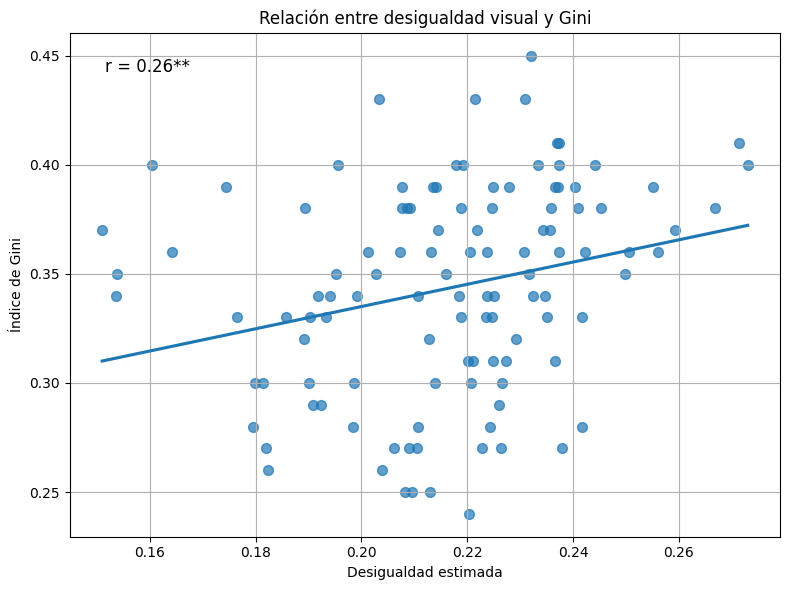

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Filtrar datos válidos
x = ciudades["Desigualdad_10km"]
y = ciudades["Gini"]
mask = x.notna() & y.notna()
x_valid = x[mask]
y_valid = y[mask]

# Calcular correlación
r, p = pearsonr(x_valid, y_valid)

# Determinar nivel de significancia
if p < 0.001:
    stars = "***"
elif p < 0.01:
    stars = "**"
elif p < 0.05:
    stars = "*"
else:
    stars = ""

# Crear gráfico
plt.figure(figsize=(8, 6))
sns.regplot(x=x_valid, y=y_valid, ci=None, scatter_kws={"s": 50, "alpha": 0.7})

# Anotar r y p
plt.text(0.05, 0.95, f"r = {r:.2f}{stars}", ha="left", va="top", transform=plt.gca().transAxes, fontsize=12)

plt.xlabel("Desigualdad estimada")
plt.ylabel("Índice de Gini")
plt.title("Relación entre desigualdad visual y Gini")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm
import numpy as np

# Definir variables
X = ciudades["Desigualdad_10km"].replace([np.inf, -np.inf], np.nan)
y = ciudades["Gini"].replace([np.inf, -np.inf], np.nan)

# Filtrar filas con NaN en X o y
mask = X.notna() & y.notna()
X, y = X[mask], y[mask]

# Agregar constante para la ordenada al origen
X = sm.add_constant(X)

# Ajustar modelo
modelo = sm.OLS(y, X).fit()

# Resumen de la regresión
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gini   R-squared:                       0.039
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     4.547
Date:                Thu, 08 May 2025   Prob (F-statistic):             0.0352
Time:                        14:19:39   Log-Likelihood:                 188.42
No. Observations:                 114   AIC:                            -372.8
Df Residuals:                     112   BIC:                            -367.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                0.2623      0.038  